In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [5]:
df.head()

,property_type,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,godrej,1.30,sector 79,8269.0,1572.0,Super Built up area 1572(146.04 sq.m.),2,2,3,...,1572.0,NaN,NaN,1,0,0,0,0,1,49.0
1,flat,shree vardhman victoria,1.63,sector 70,8358.0,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,5,3,...,1950.0,NaN,1161.0,0,1,0,0,0,1,43.0
2,flat,tulip monsella,7.40,sector 53,33198.0,2229.0,Carpet area: 2229 (207.08 sq.m.),4,4,3,...,NaN,NaN,2229.0,0,0,0,0,0,1,35.0
3,flat,raheja sampada,0.65,sector 92,4744.0,1370.0,Super Built up area 1370(127.28 sq.m.),3,2,3,...,1370.0,NaN,NaN,0,0,0,0,0,1,49.0
4,flat,signature andour heights,0.60,sector 71,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2,2,1,...,600.0,NaN,514.0,0,0,0,1,0,1,59.0


In [6]:
df.isnull().sum()

property_type             0
society                 521
price                     1
sector                    0
price_per_sqft            1
area                      1
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 21
facing                 1131
agePossession             0
super_built_up_area    1929
built_up_area          2081
carpet_area            1881
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score             13
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3850 entries, 0 to 3862
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3850 non-null   object 
 1   society              3329 non-null   object 
 2   price                3849 non-null   float64
 3   sector               3850 non-null   object 
 4   price_per_sqft       3849 non-null   float64
 5   area                 3849 non-null   float64
 6   areaWithType         3850 non-null   object 
 7   bedRoom              3850 non-null   int64  
 8   bathroom             3850 non-null   int64  
 9   balcony              3850 non-null   object 
 10  floorNum             3829 non-null   float64
 11  facing               2719 non-null   object 
 12  agePossession        3850 non-null   object 
 13  super_built_up_area  1921 non-null   float64
 14  built_up_area        1769 non-null   float64
 15  carpet_area          1969 non-null   float6

<h2> property_type vs price </h2>

/tmp/ipykernel_53921/4126812390.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='property_type', ylabel='price'>

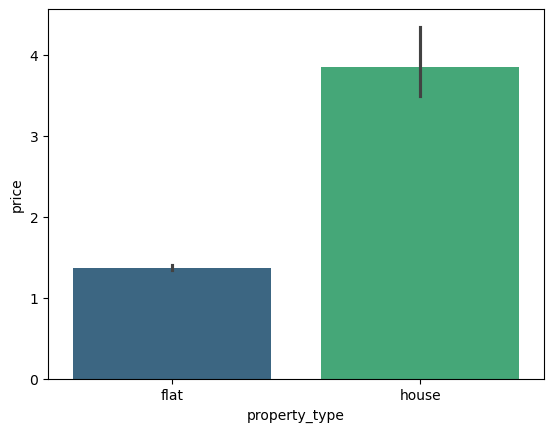

In [8]:
sns.barplot(
    data=df,
    x='property_type',
    y='price',
    estimator=np.median,
    palette = 'viridis'
)

/tmp/ipykernel_53921/2190190870.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'property_type', y = 'price', palette = 'winter')


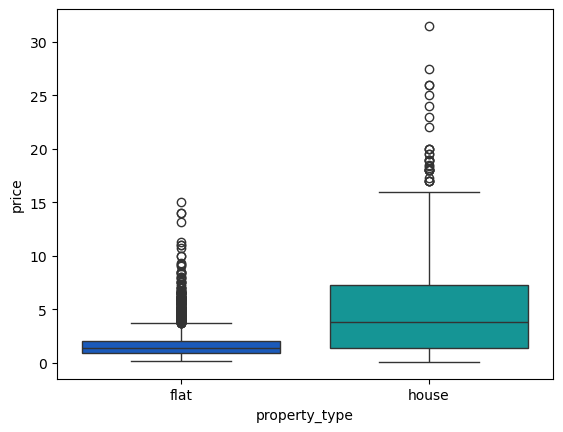

In [9]:
sns.boxplot(data = df, x = 'property_type', y = 'price', palette = 'winter')
plt.show()

<h2> property_type vs area </h2>

/tmp/ipykernel_53921/255366964.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x = 'property_type', y = 'built_up_area', palette = 'coolwarm')


<Axes: xlabel='property_type', ylabel='built_up_area'>

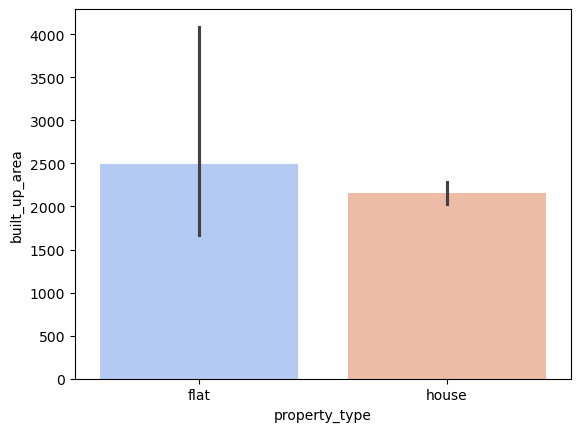

In [12]:
sns.barplot(data = df, x = 'property_type', y = 'built_up_area', palette = 'coolwarm')

In [14]:
df.groupby('property_type')['built_up_area'].mean()

property_type
flat     2496.448725
house    2153.912886
Name: built_up_area, dtype: float64

In [15]:
df.columns

Index(['property_type', 'society', 'price', 'sector', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

In [18]:
df.groupby('property_type')['floorNum'].median()

property_type
flat     7.0
house    2.0
Name: floorNum, dtype: float64

In [25]:
df.groupby(['property_type', 'furnishing_type'])['luxury_score'].mean()

property_type  furnishing_type
flat           0                  77.772727
               1                  69.394207
               2                  77.619236
house          0                  66.293103
               1                  59.504726
               2                  71.513333
Name: luxury_score, dtype: float64

<h2> property_type vs luxury_score vs furnishing_type </h2>

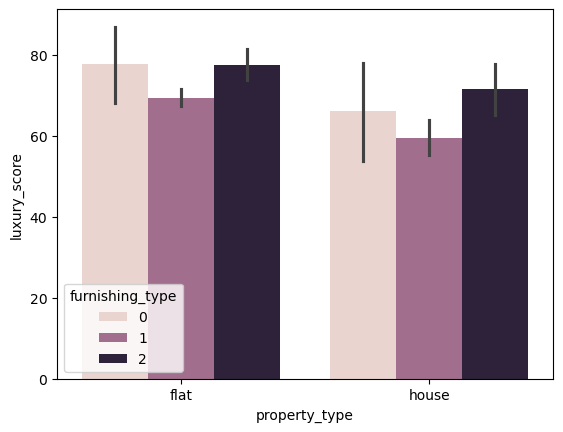

In [23]:
sns.barplot(data = df, x = 'property_type', y = 'luxury_score', hue = 'furnishing_type')
plt.show()

In [29]:
# check outliers
df[df['price_per_sqft'] > 100000][['property_type','society','sector','price','price_per_sqft','area','areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].shape

(31, 10)

<h2> society vs price </h2>

/tmp/ipykernel_53921/1314303466.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['society'].isin(top_societies)],


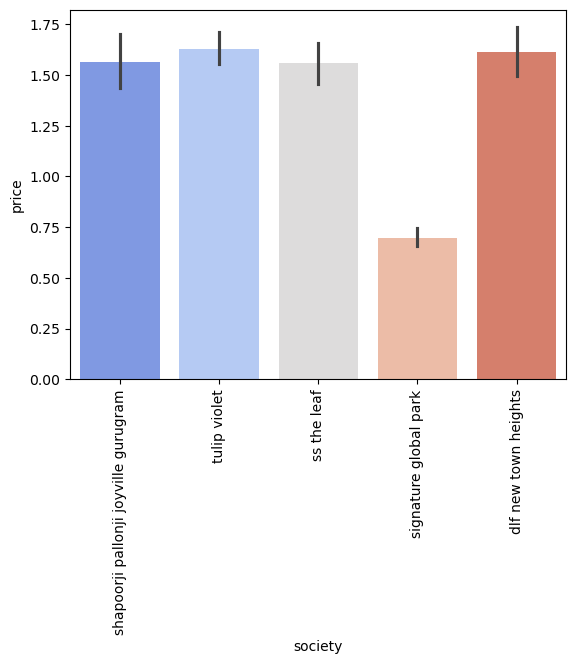

In [46]:
top_societies = df['society'].value_counts().head().index

sns.barplot(data=df[df['society'].isin(top_societies)],
            x='society',
            y='price', palette = 'coolwarm')
plt.xticks(rotation='vertical')
plt.show()

<h2> society vs luxury_score </h2>


/tmp/ipykernel_53921/1109165241.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['society'].isin(top_societies)],


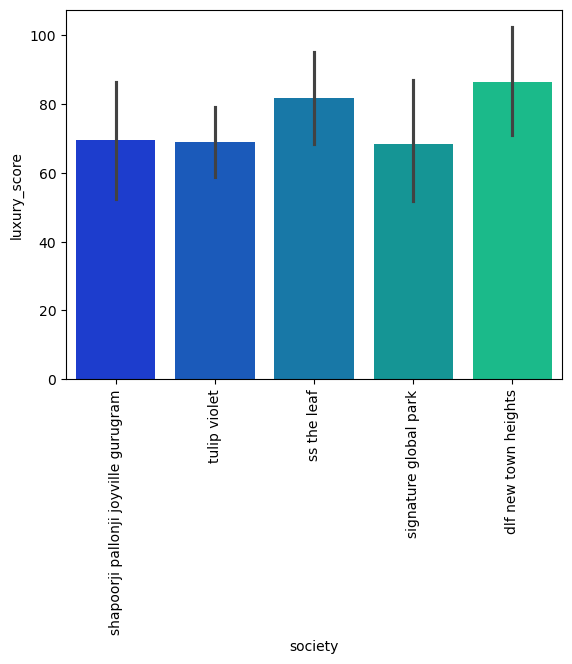

In [47]:
top_societies = df['society'].value_counts().head().index

sns.barplot(data=df[df['society'].isin(top_societies)],
            x='society',
            y='luxury_score', palette = 'winter')
plt.xticks(rotation='vertical')
plt.show()

In [55]:
df.groupby('society')[['luxury_score', 'price']].mean().sort_values(
    by='luxury_score',
    ascending=False
).head(10)

,luxury_score,price
society,,
"godrej 101, sector 79",174.0,1.25
bptp amstoria,174.0,1.90
ansal sushant lok,174.0,10.50
park view apartment,174.0,1.74
signature global infinity mall,174.0,0.41
raheja vedas,174.0,2.15
raisina residency,174.0,5.00
the serenas,174.0,0.42
emaar mgf palm terraces select,174.0,3.40


/tmp/ipykernel_53921/4119667396.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['sector'].isin(top_societies)],


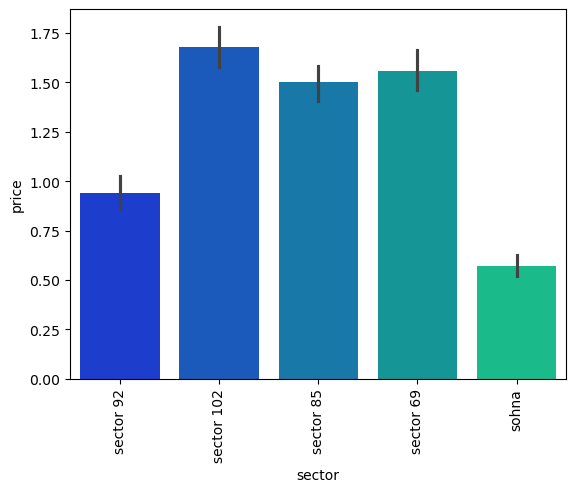

In [60]:
# sector vs price
top_societies = df['sector'].value_counts().head().index

sns.barplot(data=df[df['sector'].isin(top_societies)],
            x='sector',
            y='price', palette = 'winter')
plt.xticks(rotation='vertical')
plt.show()

In [61]:
df.groupby('sector')[['luxury_score', 'price']].mean().sort_values(
    by='luxury_score',
    ascending=False
).head(10)

,luxury_score,price
sector,,
sector 36,139.000000,0.455000
nars,128.000000,0.540000
sector 110 a,113.666667,1.816667
b block sector 43,111.666667,10.746667
sector 60,109.000000,3.987333
sector 37,96.000000,0.500000
mohan nagar,96.000000,0.860000
sector 80,94.600000,1.270000
sector 74,93.388889,1.772222


In [62]:
df.columns

Index(['property_type', 'society', 'price', 'sector', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

In [65]:
df.groupby('sector')['price_per_sqft'].mean().sort_values(
    ascending=False
).head(10)

sector
sector 24            106409.000000
golf course road      86250.000000
sector 17             71769.500000
c block sector 43     66698.750000
sector 38             58151.166667
sector 54             57362.655172
sector 12a            52711.600000
sector 25             41171.615385
sector 13             37610.500000
sector 26             36232.140000
Name: price_per_sqft, dtype: float64

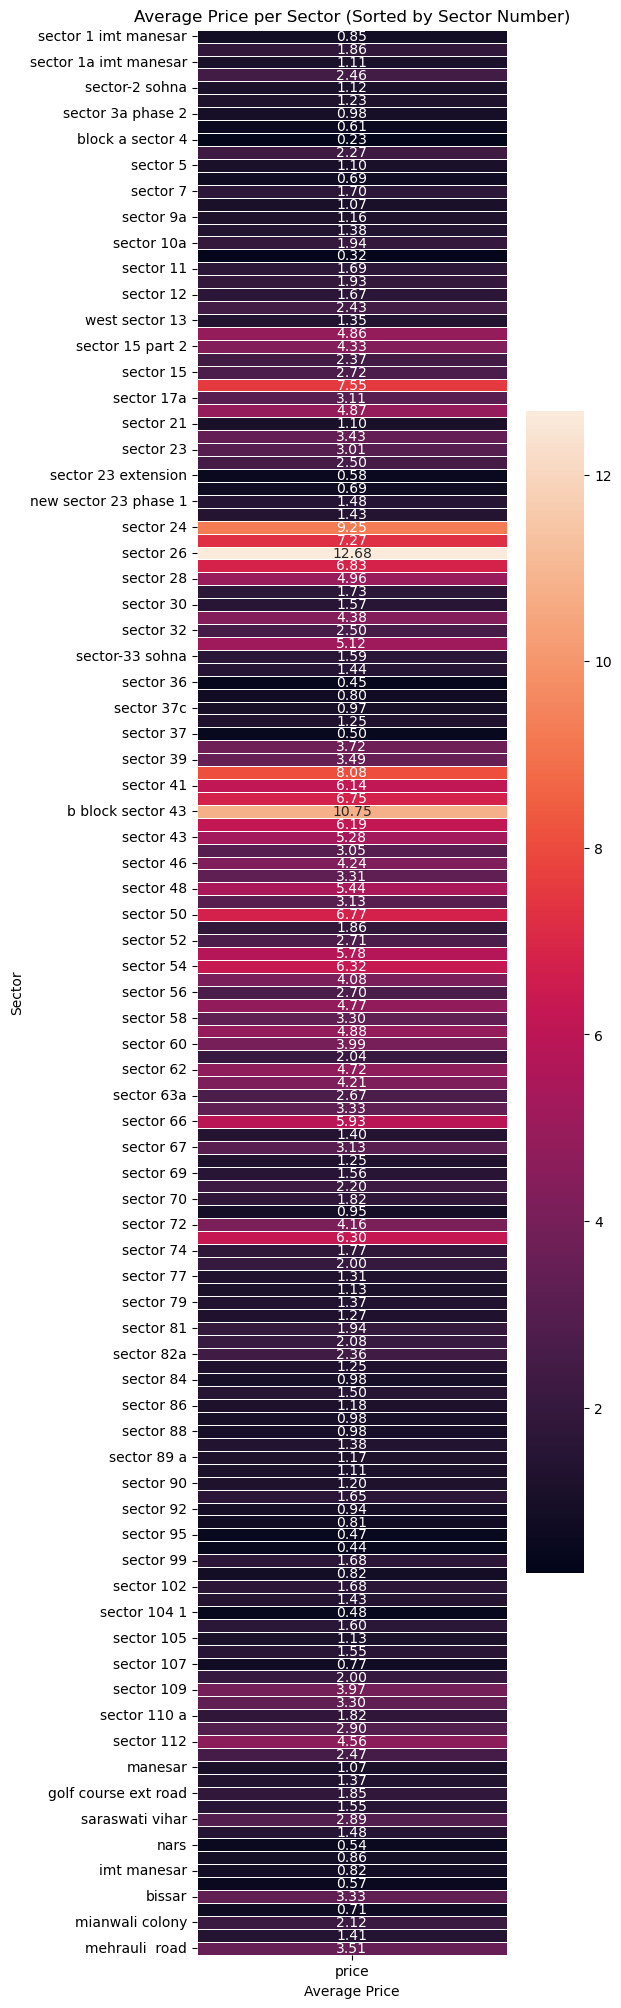

In [66]:
# sector analysis
import re
# Group by 'sector' and calculate the average price
avg_price_per_sector = df.groupby('sector')['price'].mean().reset_index()

# Function to extract sector numbers
def extract_sector_number(sector_name):
    match = re.search(r'\d+', sector_name)
    if match:
        return int(match.group())
    else:
        return float('inf')  # Return a large number for non-numbered sectors

avg_price_per_sector['sector_number'] = avg_price_per_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sector_sorted_by_sector = avg_price_per_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sector_sorted_by_sector.set_index('sector')[['price']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Price per Sector (Sorted by Sector Number)')
plt.xlabel('Average Price')
plt.ylabel('Sector')
plt.show()

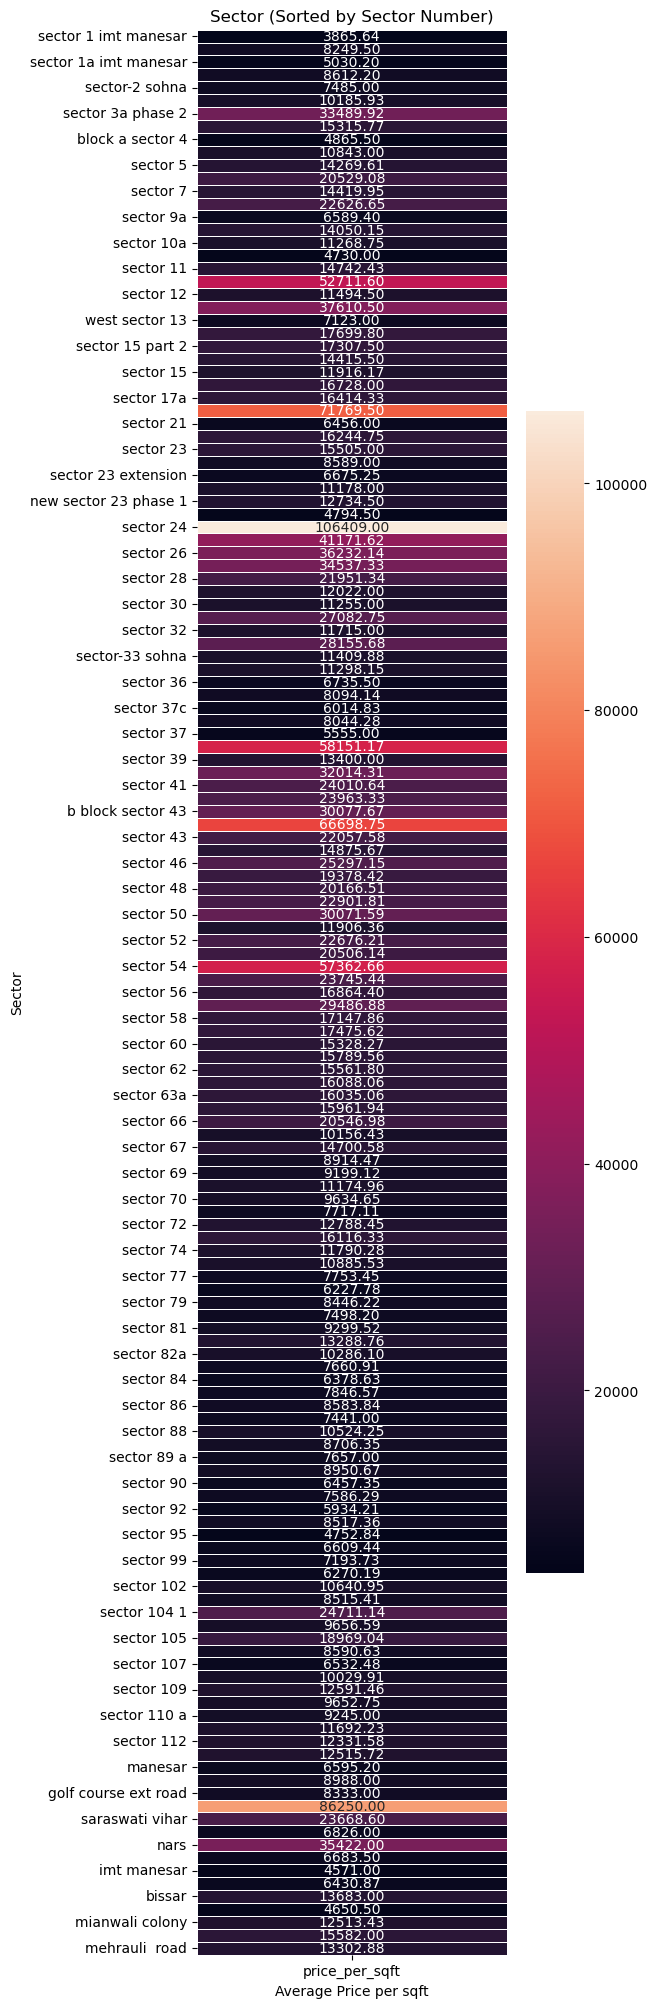

In [68]:
avg_price_per_sqft_sector = df.groupby('sector')['price_per_sqft'].mean().reset_index()

avg_price_per_sqft_sector['sector_number'] = avg_price_per_sqft_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sqft_sector_sorted_by_sector = avg_price_per_sqft_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sqft_sector_sorted_by_sector.set_index('sector')[['price_per_sqft']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Sector (Sorted by Sector Number)')
plt.xlabel('Average Price per sqft')
plt.ylabel('Sector')
plt.show()

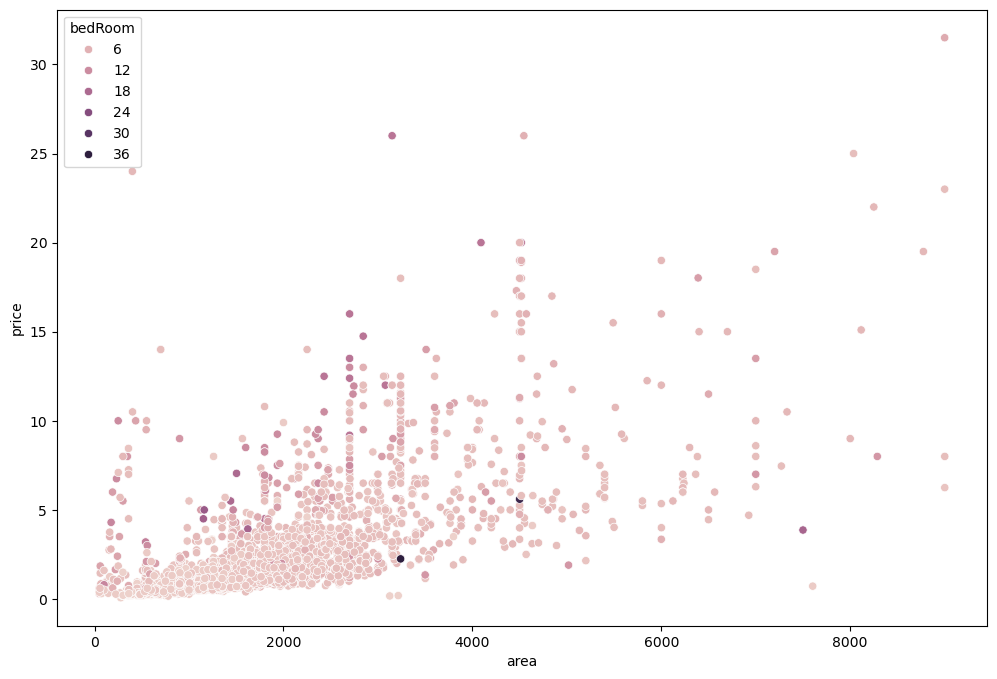

In [71]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df[df['area'] < 10000],
    x='area',
    y='price',
    hue='bedRoom'
)

plt.show()

<Axes: xlabel='area', ylabel='price'>

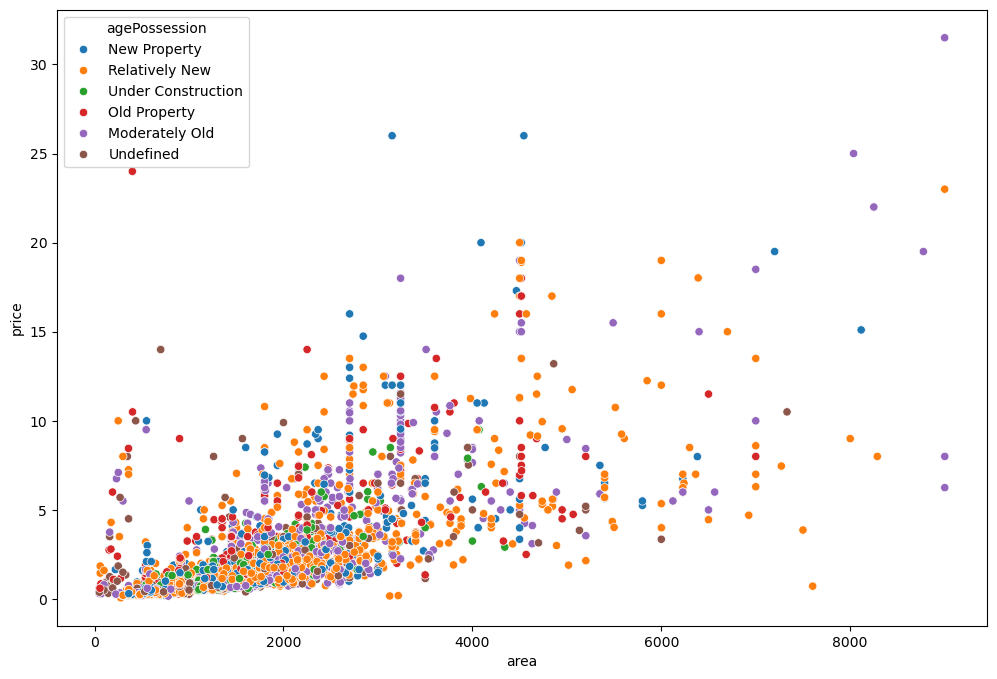

In [73]:
plt.figure(figsize=(12,8))
sns.scatterplot(data = df[df['area']<10000],x = 'area', y= 'price', hue = 'agePossession')

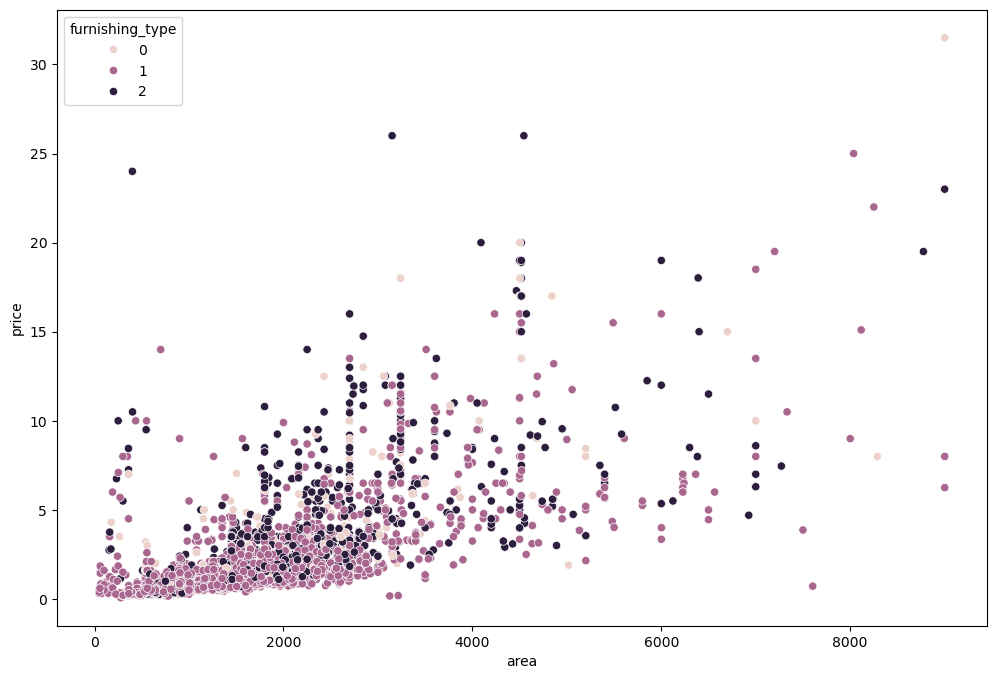

In [74]:
plt.figure(figsize=(12,8))

filtered_df = df[df['area'] < 10000]

sns.scatterplot(
    data=filtered_df,
    x='area',
    y='price',
    hue='furnishing_type'
)

plt.show()

/tmp/ipykernel_53921/3004143940.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['bedRoom'],y=df['price'],estimator=np.median, palette = 'coolwarm')


<Axes: xlabel='bedRoom', ylabel='price'>

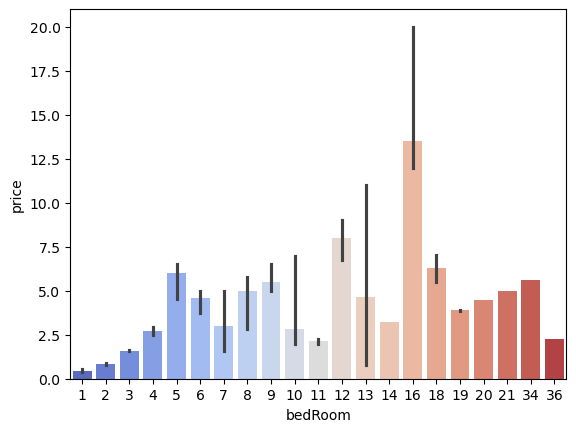

In [76]:
sns.barplot(x=df['bedRoom'],y=df['price'],estimator=np.median, palette = 'coolwarm')

/tmp/ipykernel_53921/1631368404.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['agePossession'],y=df['price'],estimator=np.median, palette = 'summer')


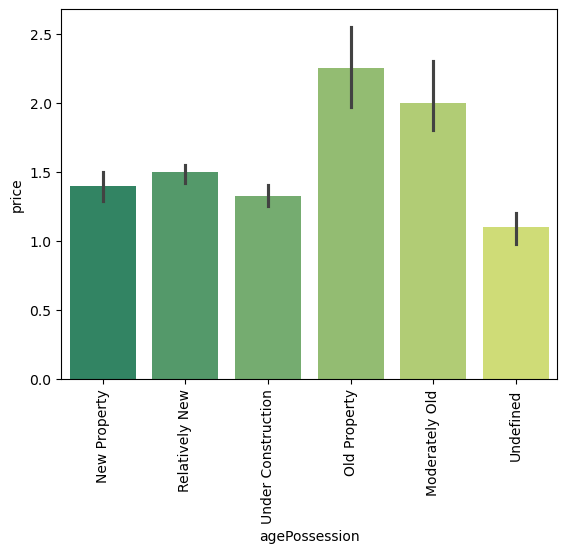

In [78]:
sns.barplot(x=df['agePossession'],y=df['price'],estimator=np.median, palette = 'summer')
plt.xticks(rotation='vertical')
plt.show()

/tmp/ipykernel_53921/2603560758.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['agePossession'],y=df['area'],estimator=np.median, palette = 'viridis')


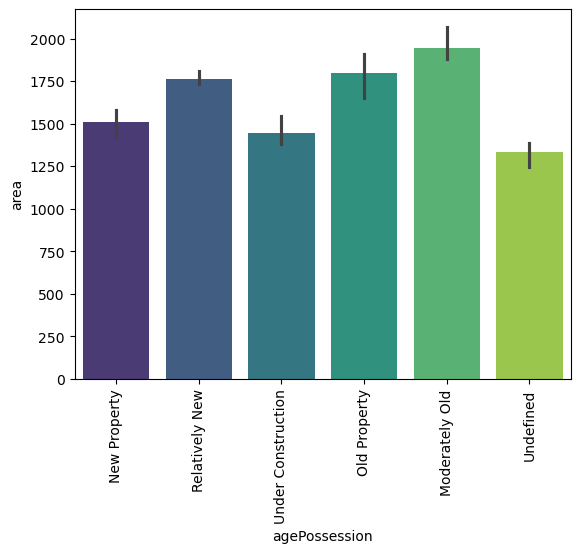

In [80]:
sns.barplot(x=df['agePossession'],y=df['area'],estimator=np.median, palette = 'viridis')
plt.xticks(rotation='vertical')
plt.show()

/tmp/ipykernel_53921/1485610925.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='furnishing_type', ylabel='price'>

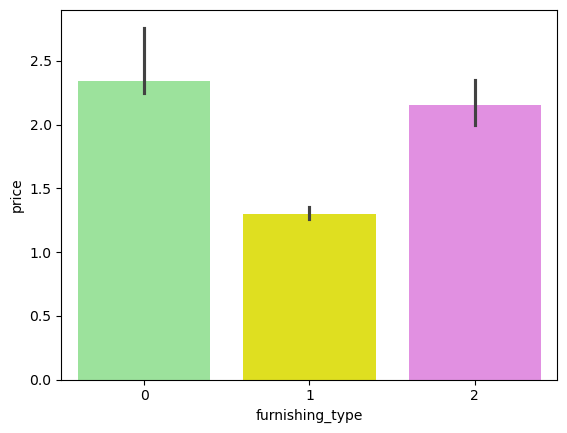

In [82]:
sns.barplot(
    x=df['furnishing_type'],
    y=df['price'],
    estimator=np.median,
    palette=['lightgreen', 'yellow', 'violet']
)

<Axes: xlabel='luxury_score', ylabel='price'>

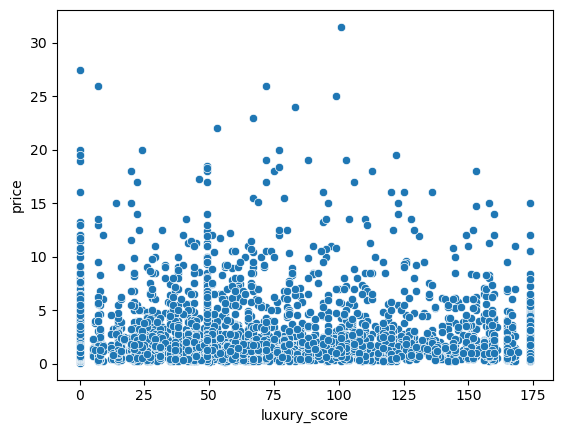

In [84]:
sns.scatterplot(
    x=df['luxury_score'],
    y=df['price']
)

<h3> Correlation </h3>

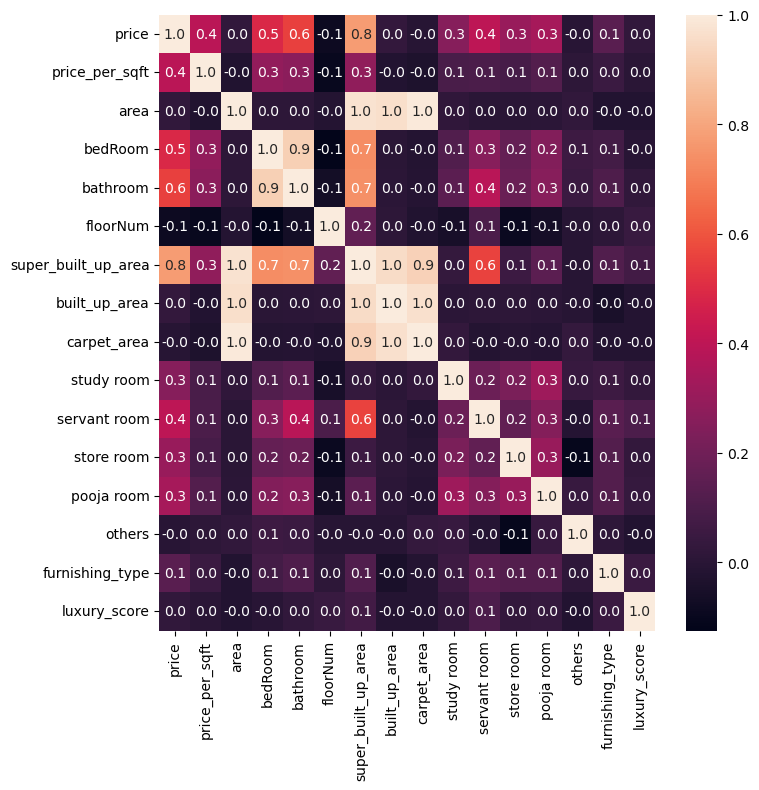

In [90]:
plt.figure(figsize=(8,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.1f'
)
plt.show()

In [92]:
df.corr(numeric_only = True)['price'].sort_values(ascending=False)

price                  1.000000
super_built_up_area    0.771952
bathroom               0.554962
bedRoom                0.487481
servant room           0.401201
price_per_sqft         0.390944
pooja room             0.340147
store room             0.304067
study room             0.256794
furnishing_type        0.135272
built_up_area          0.025745
luxury_score           0.023321
area                   0.021512
others                -0.004859
carpet_area           -0.009537
floorNum              -0.088582
Name: price, dtype: float64

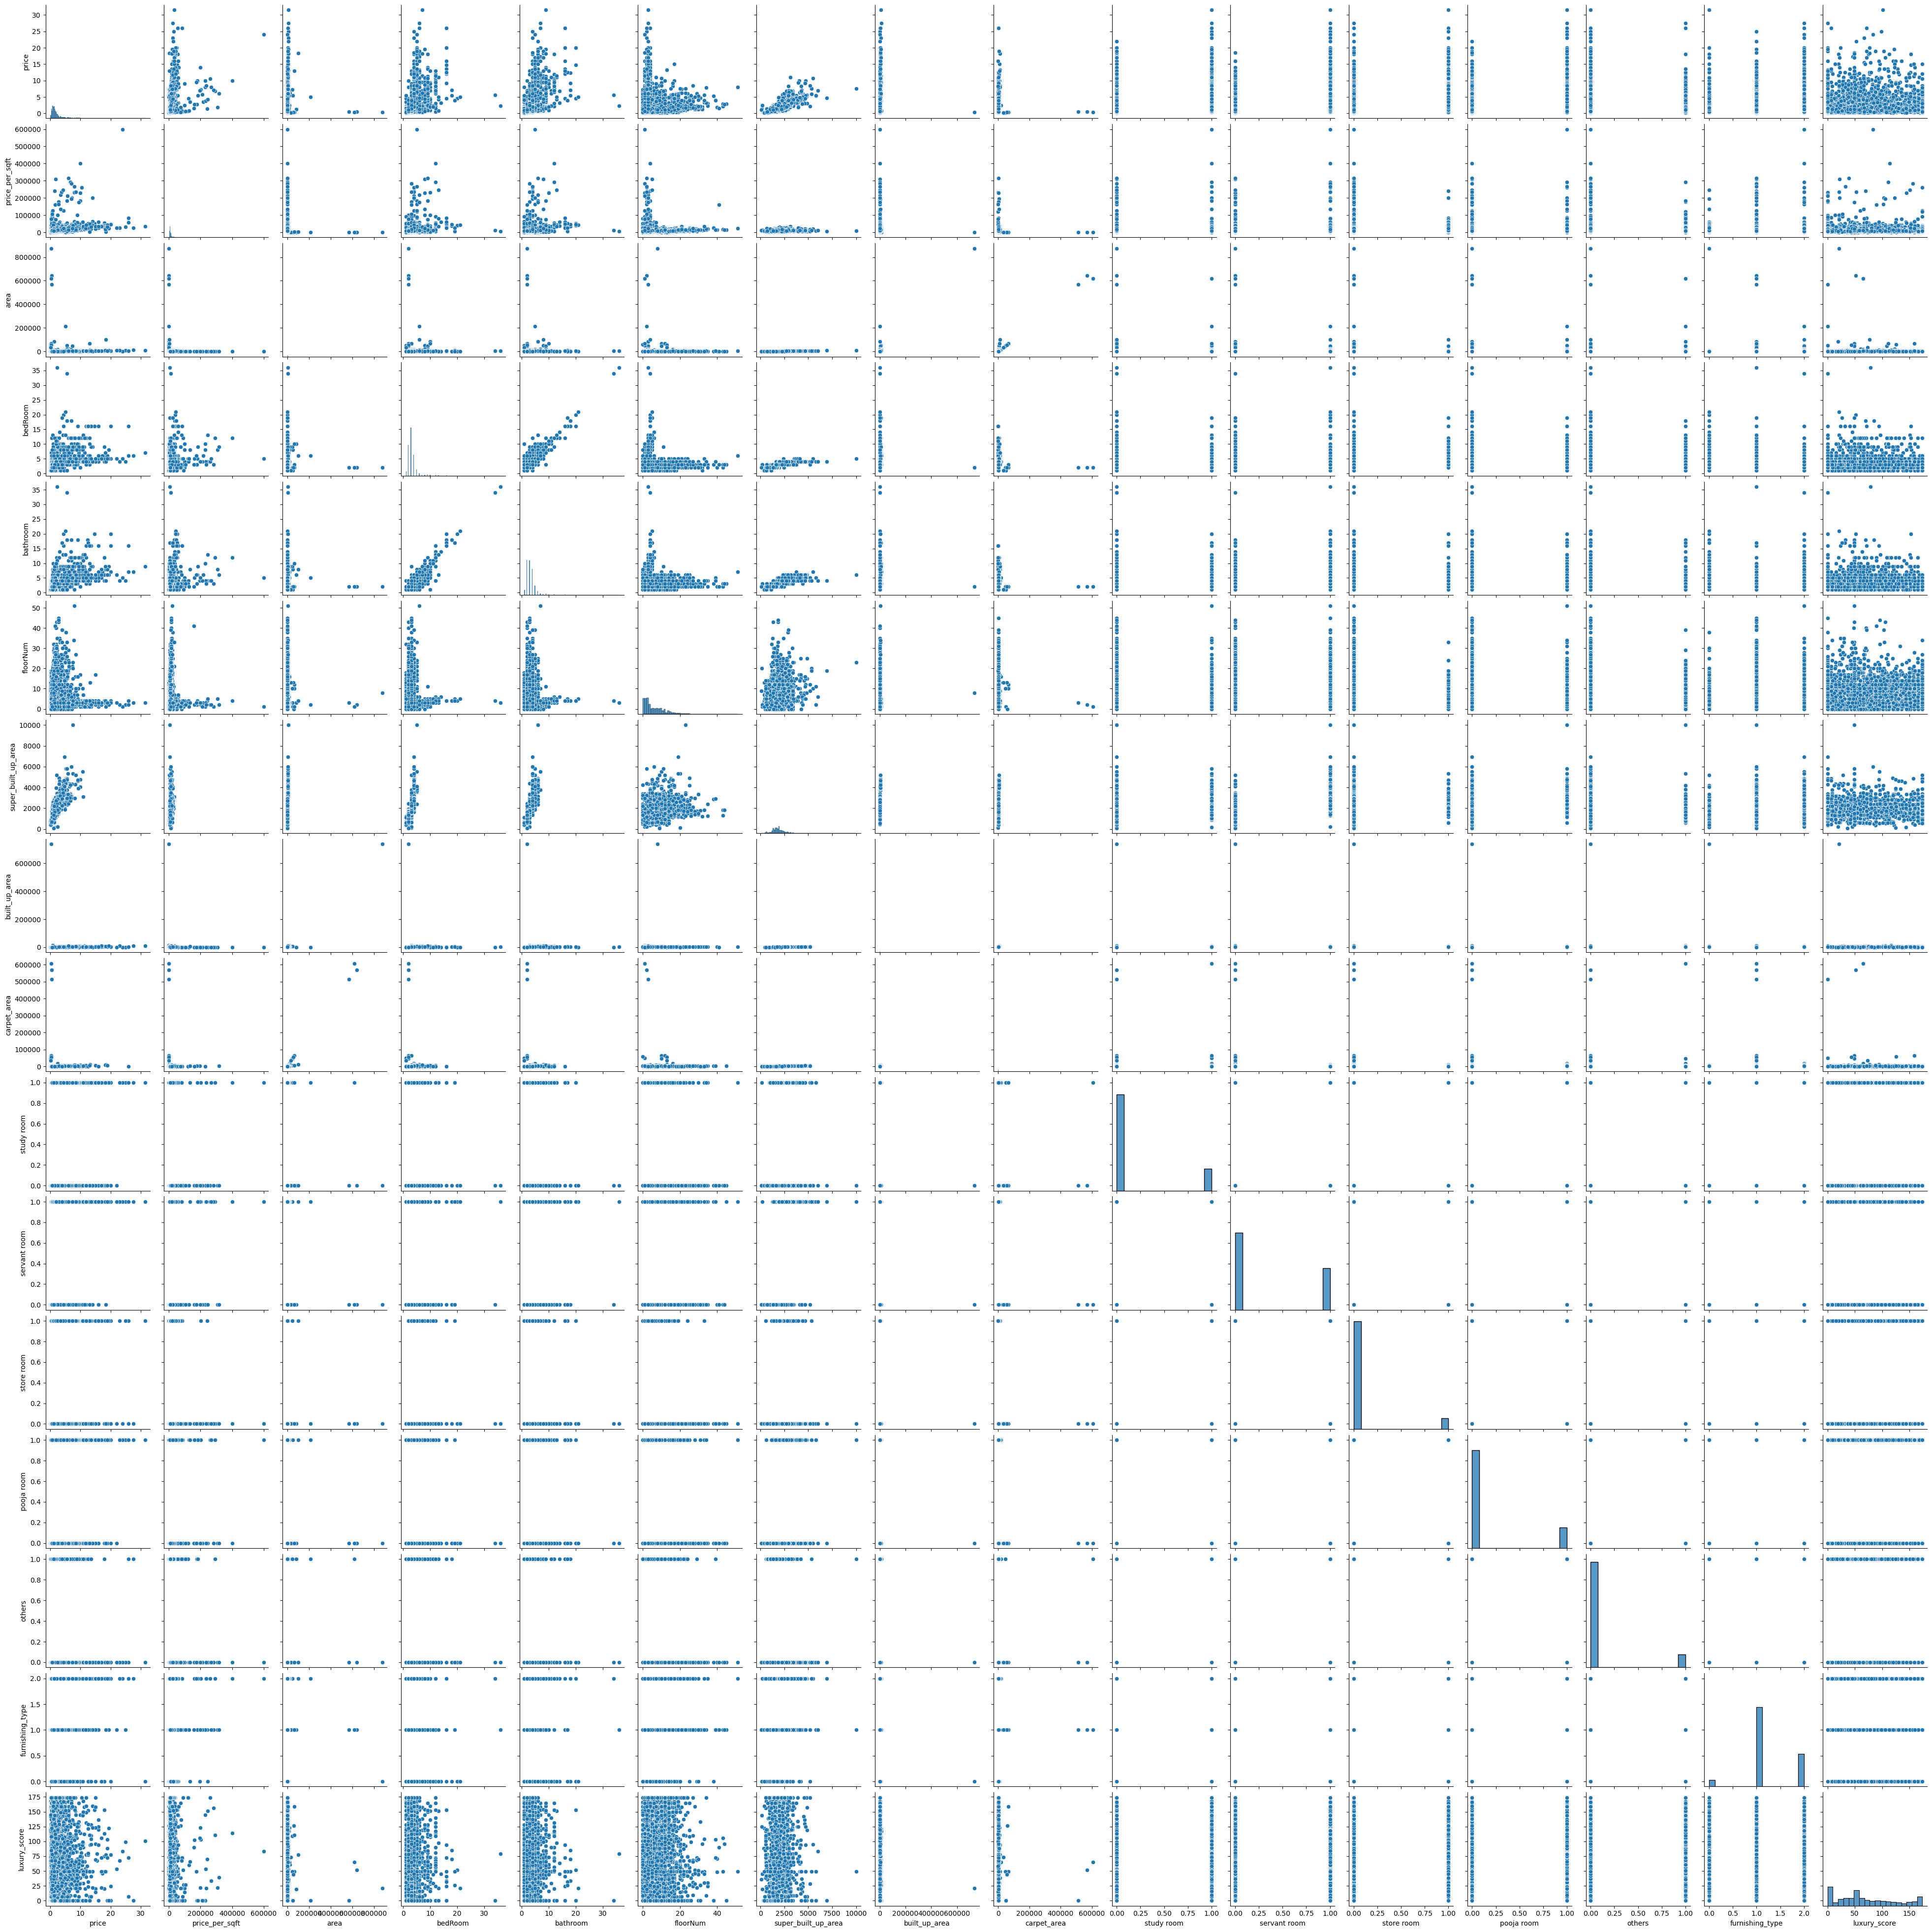

In [93]:
sns.pairplot(df)